# Customer Churn Intelligence Platform
## An End-to-End Machine Learning Approach for Customer Retention Analytics

**Author:** Badawi Aminu Muhammed

**Tools:** Python, Pandas, NumPy, Scikit-learn, XGBoost, SHAP, Plotly, Streamlit

**Objective:** Predict customer churn, identify the key drivers of customer attrition, and generate actionable retention strategies using machine learning and explainable AI.

# 1. Introduction

Customer retention is a critical business challenge, particularly in highly competitive industries such as telecommunications. Acquiring new customers is significantly more expensive than retaining existing ones, making churn prediction an essential application of machine learning.

This project develops an end-to-end Customer Churn Intelligence Platform capable of predicting whether a customer is likely to leave the company while identifying the factors contributing to that decision. Beyond prediction, the project aims to provide actionable business insights that support customer retention strategies.

The project follows the complete machine learning lifecycle, including data exploration, preprocessing, feature engineering, model development, evaluation, explainability, and deployment.

# 2. Problem Statement

Customer churn results in revenue loss, increased acquisition costs, and reduced customer lifetime value. Although organizations collect extensive customer data, identifying customers at risk of leaving before they churn remains challenging.

The objective is to leverage historical customer information to develop a predictive model capable of identifying high-risk customers and providing interpretable insights that support proactive retention strategies.

# 3. Project Objectives

The objectives of this project are:

- Explore and understand customer behaviour through exploratory data analysis.
- Identify factors associated with customer churn.
- Clean and preprocess the dataset for machine learning.
- Engineer informative features to improve predictive performance.
- Train and compare multiple machine learning models.
- Evaluate model performance using appropriate classification metrics.
- Interpret model predictions using Explainable AI (SHAP).
- Develop an interactive dashboard for business users.

# 4. Dataset Description

The project uses the IBM Telco Customer Churn dataset, which contains customer demographic information, subscribed services, account information, and churn status.

Each row represents a unique customer, while the target variable (`Churn`) indicates whether the customer discontinued the service.

The dataset includes variables related to:

- Customer demographics
- Services subscribed
- Contract information
- Billing information
- Payment methods
- Customer tenure
- Monthly and total charges

# 5. Methodology

The project follows the standard machine learning pipeline:

1. Data Loading
2. Data Inspection
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Data Preprocessing
7. Model Training
8. Model Evaluation
9. Explainable AI
10. Deployment

## 6.1 Dataset Overview

### Objective

Before building any machine learning model, it is essential to understand the structure, dimensions, and characteristics of the dataset. This provides an overview of the available features, their data types, and the overall quality of the data.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Interpretation

The dataset consists of **7,043 observations** and **21 variables**, with all columns reporting **7,043 non-null values**, indicating that there are no explicitly missing (`NaN`) values at this stage of the analysis.

The dataset contains three primary data types:

- **18 categorical (object) variables**
- **2 integer variables**
- **1 floating-point variable**

Most variables are categorical and represent customer demographics, subscribed services, payment methods, and contract information. The numerical variables include customer tenure, monthly charges, and senior citizen status.

One notable observation is that the **`TotalCharges`** variable has been stored as an **object (string)** instead of a numerical data type. Since total charges represent a continuous monetary value, this suggests a potential data quality issue that requires further investigation before model development.

Additionally, the **`customerID`** variable serves as a unique identifier for each customer. While it is useful for record identification, it does not contain predictive information and will likely be excluded during model training.

Overall, the dataset appears complete; however, validating the data type of `TotalCharges` is an important preprocessing step before proceeding with exploratory analysis and machine learning.

## 6.2 Data Quality Assessment

### Objective

Data quality assessment is a critical preprocessing step in any machine learning workflow. Poor data quality, such as missing values, duplicate records, or incorrect data types, can negatively affect model performance and lead to unreliable predictions.

This section aims to evaluate the integrity of the dataset by identifying hidden missing values, duplicate records, and inconsistencies that require cleaning before model development.

In [12]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [13]:
df["TotalCharges"].head(10)

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
5     820.50
6    1949.40
7     301.90
8    3046.05
9    3487.95
Name: TotalCharges, dtype: float64

### Interpretation

The initial inspection indicated that the dataset contained no missing values. However, after attempting to convert the `TotalCharges` column from a string (`object`) to a numeric data type, **11 missing values were introduced**.

This confirms that the dataset contained **hidden missing values**, represented as blank strings rather than standard `NaN` values. Such hidden missing values are common in real-world datasets and can easily be overlooked if only `isnull()` is used during data quality assessment.

No duplicate records were identified, indicating that each observation corresponds to a unique customer.

Overall, the dataset exhibits excellent data quality, with only a small number of hidden missing values requiring treatment before model development.

In [14]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [15]:
df[df["TotalCharges"].isnull()][
    ["customerID",
     "tenure",
     "MonthlyCharges",
     "Contract",
     "Churn"]
]

,customerID,tenure,MonthlyCharges,Contract,Churn
488,4472-LVYGI,0,52.55,Two year,No
753,3115-CZMZD,0,20.25,Two year,No
936,5709-LVOEQ,0,80.85,Two year,No
1082,4367-NUYAO,0,25.75,Two year,No
1340,1371-DWPAZ,0,56.05,Two year,No
3331,7644-OMVMY,0,19.85,Two year,No
3826,3213-VVOLG,0,25.35,Two year,No
4380,2520-SGTTA,0,20.00,Two year,No
5218,2923-ARZLG,0,19.70,One year,No
6670,4075-WKNIU,0,73.35,Two year,No


### Interpretation

Further investigation revealed that all eleven customers with missing `TotalCharges` have a tenure of **zero months**. This indicates that these customers are newly registered and have not yet completed a billing cycle, explaining why cumulative charges are unavailable.

The missing values therefore appear to be structural rather than resulting from data entry errors or system failures.

### Data Cleaning Decision

Since the missing values represent less than **0.2%** of the dataset and correspond exclusively to newly registered customers, these observations will be removed prior to model development.

Removing the affected records preserves data integrity while avoiding unnecessary imputation of a financial variable.

In [16]:
df = df.dropna().reset_index(drop=True)

In [17]:
print(df.shape)

df.isnull().sum()

(7032, 21)


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 6.3 Target Variable Analysis

### Objective

Before developing a classification model, it is important to understand the distribution of the target variable. An imbalanced target can influence model performance and may require specialized evaluation metrics or resampling techniques.

This section examines the distribution of customer churn to determine the proportion of customers who stayed versus those who left the company.

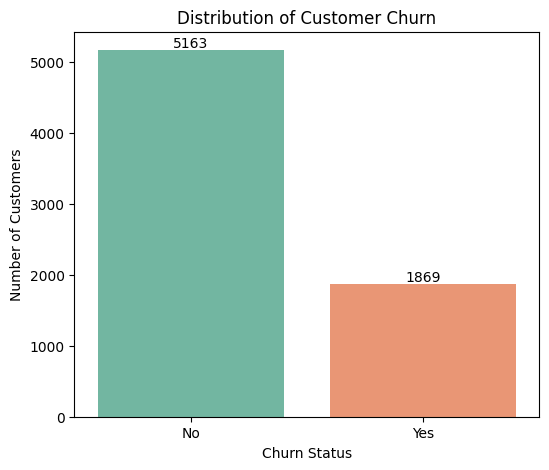

In [18]:
#distribution of churn

plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="Churn",
    palette="Set2"
)

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [20]:
#percentage distribution of churn
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churn_percentage

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64

### Interpretation

The target variable shows that approximately **73.42%** of customers remained with the company, while **26.58%** discontinued the service.

This indicates a **moderate class imbalance**, where the majority class (non-churning customers) substantially outnumbers the minority class (customers who churned). Although the imbalance is not extreme, it should be considered during model development and evaluation to ensure that the predictive model performs well for both classes.

### Business Insight

Approximately one in every four customers has churned, representing a significant loss of customers and potential revenue. This highlights customer retention as a critical business priority and reinforces the need for predictive models capable of identifying high-risk customers before they leave.

Even a modest improvement in identifying and retaining at-risk customers could translate into substantial financial benefits for the organization.

## 6.4 Contract Type and Customer Churn

### Business Question

**Does the type of customer contract influence the likelihood of churn?**

Contract duration often reflects customer commitment and loyalty. Understanding the relationship between contract type and churn can help the business design retention strategies and encourage customers to adopt longer-term subscriptions.

In [23]:
#examine the distribution
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [24]:
#cross-tabulation
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [25]:
#convert to percentages
contract_pct = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_pct.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


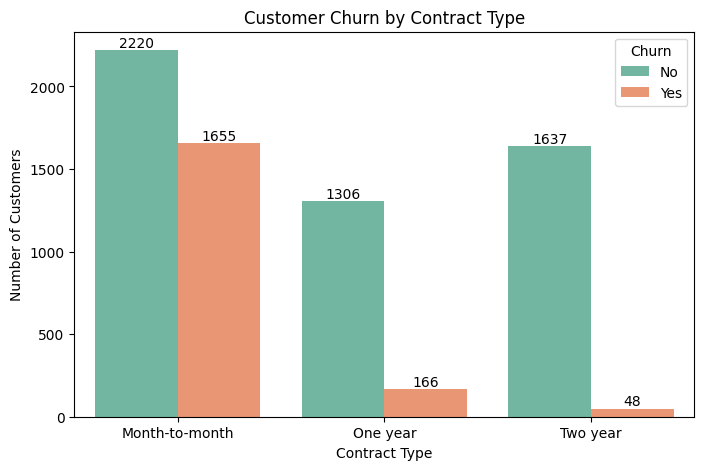

In [26]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Contract",
    hue="Churn",
    palette="Set2"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Interpretation

Contract type exhibits a strong relationship with customer churn.

Customers on **month-to-month contracts** experience the highest churn rate, with approximately **42.7%** discontinuing the service. In contrast, customers on **one-year contracts** have a substantially lower churn rate of approximately **11.3%**, while customers on **two-year contracts** demonstrate the highest retention, with only **2.9%** churning.

These findings suggest a clear inverse relationship between contract duration and customer churn: as contract length increases, the likelihood of churn decreases significantly.

### Business Insight

The results indicate that contract commitment plays a critical role in customer retention. Customers enrolled in long-term contracts are considerably less likely to leave the company than those on flexible month-to-month plans.

This may reflect increased customer commitment, stronger loyalty, or contractual obligations that discourage switching to competitors.

## 6.5 Customer Tenure and Customer Churn

### Business Question

**Does the length of time a customer has been with the company influence their likelihood of churning?**

Customer tenure is a key indicator of customer loyalty and engagement. By examining the relationship between tenure and churn, we can determine whether newly acquired customers are more likely to leave and identify opportunities for improving customer retention.

In [28]:
#summary statistics of numerical features
df.groupby("Churn")["tenure"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.65,24.08,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0


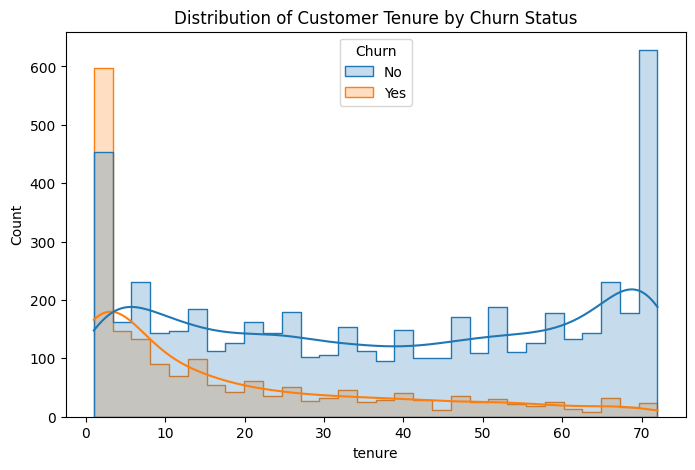

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Distribution of Customer Tenure by Churn Status")

plt.show()

### Interpretation

The descriptive statistics reveal a substantial difference in customer tenure between those who remained with the company and those who churned.

Customers who **did not churn** have an average tenure of **37.65 months**, whereas customers who **churned** have an average tenure of only **17.98 months**—less than half that of retained customers.

The median tenure further reinforces this pattern. Half of the churned customers have been with the company for **10 months or less**, while half of the retained customers have remained for at least **38 months**.

These findings suggest a strong negative relationship between customer tenure and churn, indicating that customers are most vulnerable to leaving during the early stages of their relationship with the company.

### Business Insight

The analysis suggests that customer attrition is concentrated among relatively new customers. This indicates that the company's onboarding experience, early customer engagement, and initial service satisfaction may play a significant role in determining long-term retention.

Once customers remain with the company for an extended period, they appear considerably more likely to continue using the service, demonstrating increased loyalty over time.

## 6.6 Monthly Charges and Customer Churn

### Business Question

**Does the amount a customer pays each month influence their likelihood of churning?**

Pricing plays a crucial role in customer retention. If customers with higher monthly charges are more likely to leave, it may indicate pricing dissatisfaction, perceived lack of value, or stronger competition from alternative providers. This analysis explores whether monthly charges are associated with customer churn.

In [31]:
df.groupby("Churn")["MonthlyCharges"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.31,31.09,18.25,25.10,64.45,88.48,118.75
Yes,1869.0,74.44,24.67,18.85,56.15,79.65,94.20,118.35


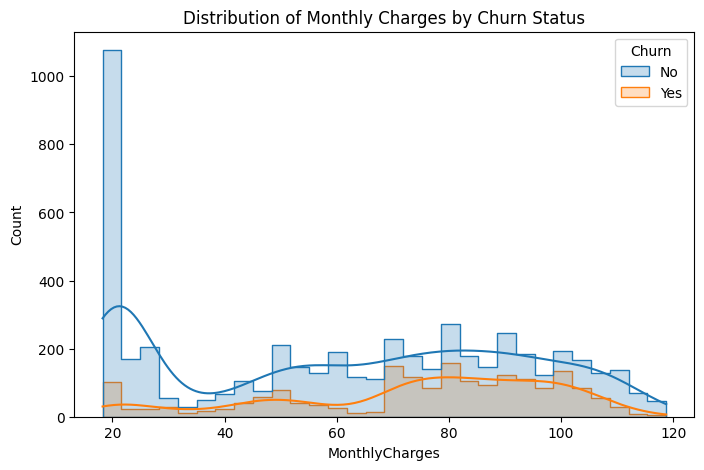

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    kde=True,
    bins=30,
    element="step"
)

plt.title("Distribution of Monthly Charges by Churn Status")

plt.show()

### 📖 Interpretation

Customers who churned pay noticeably higher monthly charges than those who remained with the company.

The average monthly charge for customers who churned is **\$74.44**, compared to **\$61.31** for retained customers. Similarly, the median monthly charge is **\$79.65** for churned customers versus **\$64.45** for retained customers.

Although both groups have similar minimum and maximum monthly charges, the higher average and median among churned customers suggest that customers paying more each month are generally more likely to discontinue the service.

This relationship indicates that monthly pricing may influence customer retention, although it is unlikely to be the sole driver of churn.

## 6.7 Technical Support and Customer Churn

### Business Question

**Does access to technical support influence customer churn?**

Technical support plays an important role in customer satisfaction and service quality. Customers who receive timely assistance are generally more likely to remain loyal to a service provider. This analysis investigates whether the availability of technical support is associated with customer retention.

In [33]:
df["TechSupport"].value_counts()

TechSupport
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64

In [34]:
#percentage table
tech_pct = (
    pd.crosstab(
        df["TechSupport"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

tech_pct

Churn,No,Yes
TechSupport,,
No,58.35,41.65
No internet service,92.57,7.43
Yes,84.80,15.20


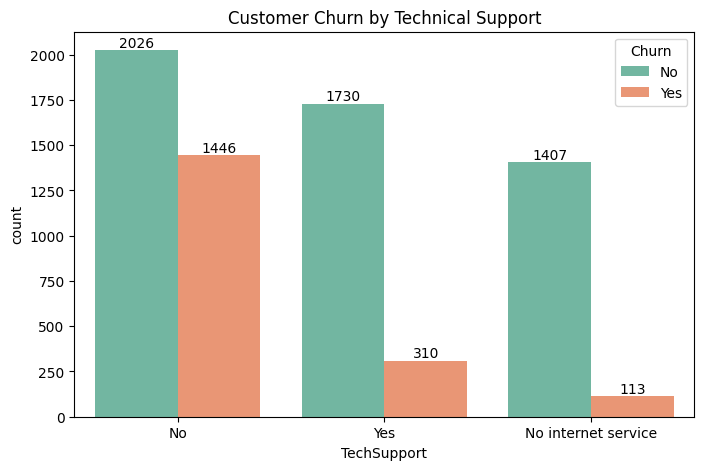

In [35]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn",
    palette="Set2"
)

plt.title("Customer Churn by Technical Support")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### 📖 Interpretation

Technical support exhibits a clear relationship with customer churn.

Among customers **without technical support**, approximately **41.65%** churned, compared to only **15.20%** of customers who subscribed to technical support.

Customers without internet service showed the lowest churn rate (**7.43%**). However, because technical support is not applicable to customers without internet service, this category should be interpreted separately.

Overall, the results suggest that customers with access to technical support are substantially more likely to remain with the company than those without support.

# 6.8 Executive Summary of Exploratory Data Analysis

The exploratory data analysis identified several important factors associated with customer churn.

### Key Findings

1. **Contract Type**
   - Customers on month-to-month contracts exhibited the highest churn rates.
   - Long-term contracts were strongly associated with customer retention.

2. **Customer Tenure**
   - Customers with shorter tenures were considerably more likely to churn.
   - The first year of the customer lifecycle appears to be the highest-risk period.

3. **Monthly Charges**
   - Customers paying higher monthly charges demonstrated an increased likelihood of churn.
   - Pricing should be evaluated alongside perceived service value.

4. **Technical Support**
   - Customers without technical support experienced substantially higher churn rates.
   - Access to effective customer support appears to improve retention.

### Overall Conclusion

The exploratory analysis indicates that customer churn is influenced by a combination of contractual commitment, customer experience, service value, and customer tenure. These findings provide a strong foundation for developing predictive machine learning models and designing targeted customer retention strategies.

# 7. Data Preprocessing

## Objective

Raw data cannot be directly used for machine learning because it may contain irrelevant features, inconsistent data types, and categorical variables that require transformation.

This section prepares the dataset for model development by removing unnecessary variables, encoding categorical features, and constructing a preprocessing pipeline that ensures consistent data transformation during both training and inference.

In [36]:
#remove customer ID
df = df.drop(columns=["customerID"])

### Feature Selection

The `customerID` variable uniquely identifies each customer but does not describe customer behaviour or service usage.

Since machine learning models cannot learn meaningful patterns from arbitrary identifiers, this feature is removed prior to model training.

In [37]:
#separate features and target
X = df.drop(columns=["Churn"])

y = df["Churn"]

### Defining Features and Target Variable

The dataset is separated into:

- **Features (`X`)**: Customer characteristics used to predict churn.
- **Target (`y`)**: Customer churn status.

In [38]:
#identify categories
categorical_features = X.select_dtypes(include="object").columns.tolist()

numerical_features = X.select_dtypes(exclude="object").columns.tolist()

print(categorical_features)

print(numerical_features)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [39]:
#train/test spli
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [41]:
#procesing pipline
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

## 7.2 Baseline Model

### Objective

A baseline model provides an initial performance benchmark against which more complex machine learning algorithms can be compared.

Logistic Regression was selected as the baseline because it is computationally efficient, interpretable, and well-suited for binary classification problems.

In [45]:
#build the pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

In [55]:
logistic_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [56]:
#train
y_pred = logistic_pipeline.predict(X_test)

y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="Yes")
recall = recall_score(y_test, y_pred, pos_label="Yes")
f1 = f1_score(y_test, y_pred, pos_label="Yes")
roc_auc = roc_auc_score((y_test == "Yes").astype(int), y_prob)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.804
Precision: 0.648
Recall   : 0.572
F1 Score : 0.608
ROC-AUC  : 0.836

Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Confusion Matrix:
[[917 116]
 [160 214]]


# 7.3 Baseline Model Evaluation

### 📖 Interpretation

The Logistic Regression model achieved an overall accuracy of **80.4%**, indicating good predictive performance on the test dataset.

The model obtained a **Precision of 64.8%**, meaning that approximately two out of every three customers predicted to churn were correctly identified.

The **Recall of 57.2%** indicates that the model successfully identified slightly more than half of the customers who actually churned. While this represents a reasonable baseline, some at-risk customers remain undetected.

The model achieved an **F1-score of 60.8%**, reflecting a balanced trade-off between Precision and Recall.

Finally, the **ROC-AUC score of 0.836** demonstrates strong discriminative ability, suggesting that the model effectively distinguishes between customers who churn and those who remain.

# 7.4 Model Evaluation Utility

Rather than evaluating each model separately, a reusable evaluation function is developed to ensure consistency across all machine learning models. This approach promotes cleaner code, easier model comparison, and improved maintainability.

In [75]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

model_results = []

In [76]:
def evaluate_model(name, model, X_test, y_test):
    """
    Evaluate a trained classification model and
    store its performance metrics.
    """

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            pos_label="Yes"
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            pos_label="Yes"
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred,
            pos_label="Yes"
        ),
        "ROC-AUC": roc_auc_score(
            (y_test == "Yes").astype(int),
            y_prob
        )
    }

    model_results.append(results)

    return pd.DataFrame(model_results).round(3)

In [77]:
model_results = []
results_df = evaluate_model(
    "Logistic Regression",
    logistic_pipeline,
    X_test,
    y_test
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804,0.648,0.572,0.608,0.836


In [78]:
#decision tree
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

decision_tree_pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 7.5 Decision Tree Classifier

### Objective

Decision Trees are non-linear machine learning models capable of learning hierarchical decision rules from data. Unlike Logistic Regression, they can capture complex feature interactions without requiring explicit feature engineering.

The Decision Tree model is evaluated to determine whether modeling non-linear relationships improves customer churn prediction.

In [79]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=5,          # Prevent excessive overfitting
        min_samples_split=20,
        min_samples_leaf=10
    ))
])

In [80]:
#train
decision_tree_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [81]:
#evaluate
results_df = evaluate_model(
    "Decision Tree",
    decision_tree_pipeline,
    X_test,
    y_test
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804,0.648,0.572,0.608,0.836
1,Decision Tree,0.790,0.604,0.615,0.609,0.828


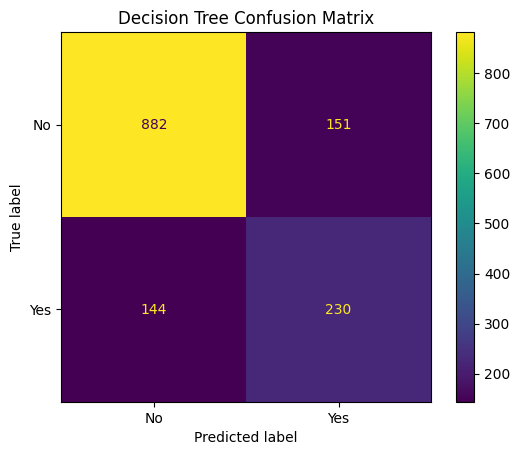

In [82]:
#confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    decision_tree_pipeline.predict(X_test)
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

### 7.5 Decision Tree Evaluation

#### 📖 Interpretation

The Decision Tree classifier achieved an overall accuracy of **79.0%**, which is slightly lower than the Logistic Regression baseline.

However, the Decision Tree achieved a **higher Recall (61.5%)**, indicating that it successfully identified more customers who actually churned. This improvement came at the expense of Precision, meaning the model generated more false positive predictions.

The ROC-AUC score of **0.828** indicates good discrimination between churning and non-churning customers, although it remains slightly below that of the Logistic Regression model.

In [83]:
#Random forest
from sklearn.ensemble import RandomForestClassifier

In [84]:
#pipeline
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

In [85]:
#train & evaluate
random_forest_pipeline.fit(
    X_train,
    y_train
)

results_df = evaluate_model(
    "Random Forest",
    random_forest_pipeline,
    X_test,
    y_test
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804,0.648,0.572,0.608,0.836
1,Decision Tree,0.790,0.604,0.615,0.609,0.828
2,Random Forest,0.792,0.637,0.503,0.562,0.834


## 7.6 Extreme Gradient Boosting (XGBoost)

### Objective

Extreme Gradient Boosting (XGBoost) is an ensemble learning algorithm that builds trees sequentially, with each new tree correcting the errors of previous trees. It is widely regarded as one of the most effective algorithms for structured (tabular) datasets due to its strong predictive performance and built-in regularization mechanisms.

The XGBoost model is evaluated to determine whether gradient boosting improves customer churn prediction over the previously evaluated models.

In [86]:
#XGBoost
from xgboost import XGBClassifier

#encode target
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [88]:
#build pipeline & train
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

xgb_pipeline.fit(
    X_train,
    y_train_encoded
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [89]:
#evaluate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = xgb_pipeline.predict(X_test)
y_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test_encoded, y_pred))
print("Precision:", precision_score(y_test_encoded, y_pred))
print("Recall   :", recall_score(y_test_encoded, y_pred))
print("F1 Score :", f1_score(y_test_encoded, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test_encoded, y_prob))

Accuracy : 0.7789623312011372
Precision: 0.5957446808510638
Recall   : 0.5240641711229946
F1 Score : 0.5576102418207681
ROC-AUC  : 0.8229094946964088


In [91]:
#hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["liblinear", "lbfgs"],
    "classifier__penalty": ["l2"]
}

search = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
print(search.best_params_)
print(search.best_score_)

{'classifier__solver': 'lbfgs', 'classifier__penalty': 'l2', 'classifier__C': 100}
0.8462408998518063


In [92]:
#save best model
best_model = search.best_estimator_

In [93]:
#evaluate tuned models
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred, pos_label='Yes'):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred, pos_label='Yes'):.3f}")
print(f"F1 Score : {f1_score(y_test, y_pred, pos_label='Yes'):.3f}")
print(f"ROC-AUC  : {roc_auc_score((y_test=='Yes').astype(int), y_prob):.3f}")

Accuracy : 0.797
Precision: 0.632
Recall   : 0.564
F1 Score : 0.596
ROC-AUC  : 0.835


In [96]:
#feature importance
feature_names = logistic_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = logistic_pipeline.named_steps["classifier"].coef_[0]
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance_df["Abs_Coefficient"] = importance_df["Coefficient"].abs()

importance_df = importance_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

importance_df.head(20)

,Feature,Coefficient,Abs_Coefficient
1,num__tenure,-1.352313,1.352313
38,cat__Contract_Two year,-0.779030,0.779030
3,num__TotalCharges,0.644014,0.644014
15,cat__InternetService_DSL,-0.616132,0.616132
36,cat__Contract_Month-to-month,0.613846,0.613846
16,cat__InternetService_Fiber optic,0.590184,0.590184
2,num__MonthlyCharges,-0.541006,0.541006
39,cat__PaperlessBilling_No,-0.300387,0.300387
12,cat__MultipleLines_No,-0.293470,0.293470
17,cat__InternetService_No,-0.283724,0.283724


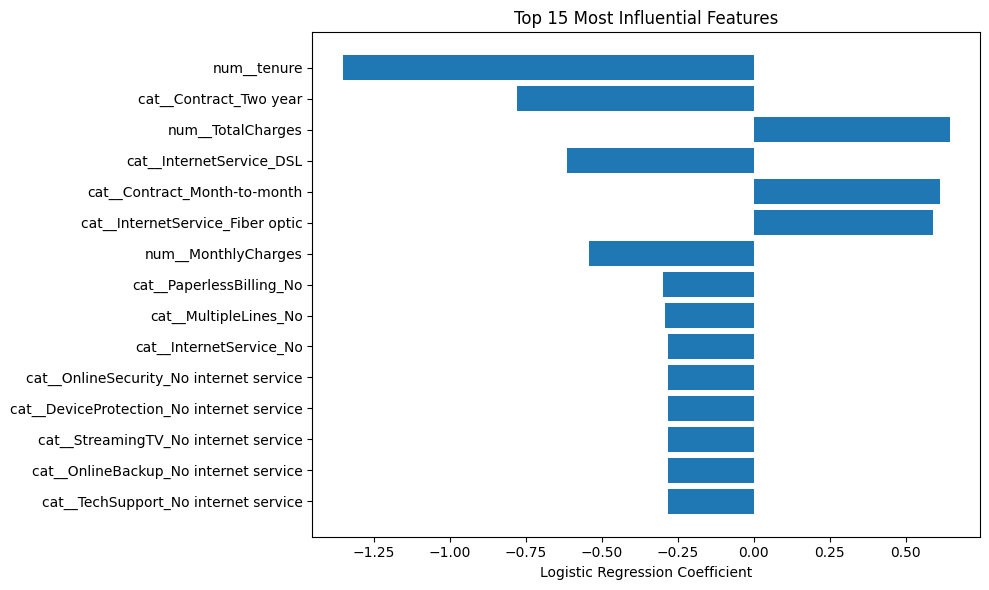

In [97]:
#visualization
import matplotlib.pyplot as plt

top_features = importance_df.head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.gca().invert_yaxis()
plt.xlabel("Logistic Regression Coefficient")
plt.title("Top 15 Most Influential Features")
plt.tight_layout()
plt.show()

# 7.7 Feature Importance Analysis

## Interpretation

The Logistic Regression coefficients provide insight into the variables that most strongly influence customer churn predictions.

Key observations include:

- **Tenure** exhibited the largest negative coefficient (-1.352), indicating that customers with longer service durations are substantially less likely to churn.

- Customers on **Two-Year Contracts** also showed a strong negative association with churn, suggesting that long-term contractual commitments significantly improve customer retention.

- **Month-to-Month Contracts** displayed one of the strongest positive coefficients, indicating that customers without long-term contractual commitments are considerably more likely to discontinue the service.

- Customers subscribed to **Fiber Optic Internet** were associated with an increased likelihood of churn, whereas customers using **DSL Internet** demonstrated a lower propensity to churn.

- **Monthly Charges** contributed meaningfully to the prediction, suggesting that pricing influences customer retention behaviour.

Overall, the model indicates that **contract type, customer tenure, internet service type, and monthly charges are the most influential predictors of customer churn.**

In [98]:
#save final model
import joblib

joblib.dump(logistic_pipeline, "churn_prediction_pipeline.pkl")

print("Model saved successfully!")

Model saved successfully!
